Dans ce notebook, plusieurs méthodes ont été testées afin de choisir la meilleure. Ce sera le dernier modèle, dont la soumission sera exportée à la fin, avec le score final visible sur Kaggle. On fait référence à quelques notebooks comme sources tout au long de ce travail. Enfin, parmi les difficultés rencontrées, on note la présence de valeurs manquantes pour des raisons inconnues. Il semble que les données aient été générées artificiellement, notamment avec un grand nombre d'individus ayant un nombre élevé de caractéristiques manquantes.

In [1]:
# librairies dont nous aurons besoin:
import os
import numpy as np
import pandas as pd
#!pip install sweetviz
#import sweetviz 
import optuna

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import statsmodels.api as sm
from numpy import median, mean
from collections import Counter
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, PowerTransformer, StandardScaler 
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import log_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.utils.class_weight import compute_class_weight

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold, cross_val_score, GridSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.metrics import (
    accuracy_score, log_loss, classification_report, mean_squared_error
)

import warnings 
warnings.filterwarnings("ignore")

for dirname, _, filenames in os.walk('/kaggle/input/classification-cirrhosis'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# https://www.kaggle.com/code/abhirupghosh184098/cirrhosis-predictor-eda-ensemble-nn
# https://www.kaggle.com/code/ashishkumarak/ps3e26-liver-cirrhosis-eda-model

/kaggle/input/classification-cirrhosis/sample_submission.csv
/kaggle/input/classification-cirrhosis/test_df_clean.csv
/kaggle/input/classification-cirrhosis/train_df_clean.csv
/kaggle/input/classification-cirrhosis/train.csv
/kaggle/input/classification-cirrhosis/test.csv


In [2]:
# train_df_clean.csv et test_df_clean.csv sont les tables corrigées et 
# nettoyées des anomalies, comme par exemple une modalité qui apparaît de manière anormale, etc. 
# Le prétraitement à ce niveau est détaillé à l'étape EDA.
train = pd.read_csv("/kaggle/input/classification-cirrhosis/train_df_clean.csv", 
                      delimiter = ",",
                      header = 0)

test = pd.read_csv("/kaggle/input/classification-cirrhosis/test_df_clean.csv", 
                      delimiter = ",",
                      header = 0)

train.shape, test.shape

((15000, 20), (10000, 19))

Base train:

In [3]:
train1 = train.copy()
test1 = test.copy()
train1.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,1055.0,NaN,54,F,NaN,NaN,NaN,N,1.3,NaN,3.64,NaN,NaN,NaN,NaN,209.0,10.5,3.0,C
1,1,3282.0,Placebo,49,F,N,Y,Y,N,0.7,3.09,3.60,96.0,1142.0,71.3,106.0,240.0,12.4,4.0,C
2,2,1653.0,NaN,56,F,NaN,NaN,NaN,N,2.2,NaN,3.64,NaN,NaN,NaN,NaN,139.0,9.5,2.0,C
3,3,999.0,D-penicillamine,62,F,N,Y,N,N,1.0,4.98,3.35,89.0,1601.0,164.3,85.0,394.0,9.7,3.0,C
4,4,2202.0,NaN,49,F,NaN,NaN,NaN,N,17.2,NaN,3.15,NaN,NaN,NaN,NaN,432.0,11.2,3.0,C


In [4]:
#train_description = sweetviz.analyze([train1, "Train"])
#train_description.show_notebook(w="100%", h="full")

In [5]:
test1.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,15000,611.0,D-penicillamine,60,F,N,Y,N,N,0.8,1.98,3.90,39.0,855.0,66.65,56.0,295.0,10.5,4.0
1,15001,2103.0,NaN,60,F,NaN,NaN,NaN,N,0.6,NaN,3.81,NaN,NaN,NaN,NaN,269.0,10.5,3.0
2,15002,130.0,NaN,63,F,NaN,NaN,NaN,N,0.7,NaN,3.94,NaN,NaN,NaN,NaN,425.0,10.8,4.0
3,15003,1635.0,NaN,55,F,NaN,NaN,NaN,N,0.6,NaN,3.50,NaN,NaN,NaN,NaN,248.0,10.3,2.0
4,15004,3336.0,D-penicillamine,41,F,N,N,N,N,0.5,NaN,4.52,29.0,766.0,74.40,NaN,474.0,10.1,2.0


In [6]:
train1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           8564 non-null   object 
 3   Age            15000 non-null  int64  
 4   Sex            15000 non-null  object 
 5   Ascites        8561 non-null   object 
 6   Hepatomegaly   8563 non-null   object 
 7   Spiders        8555 non-null   object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    6669 non-null   float64
 11  Albumin        15000 non-null  float64
 12  Copper         8452 non-null   float64
 13  Alk_Phos       8558 non-null   float64
 14  SGOT           8555 non-null   float64
 15  Tryglicerides  6630 non-null   float64
 16  Platelets      14414 non-null  float64
 17  Prothrombin    14974 non-null  float64
 18  Stage 

In [7]:
test1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   N_Days         10000 non-null  float64
 2   Drug           5659 non-null   object 
 3   Age            10000 non-null  int64  
 4   Sex            10000 non-null  object 
 5   Ascites        5666 non-null   object 
 6   Hepatomegaly   5665 non-null   object 
 7   Spiders        5659 non-null   object 
 8   Edema          10000 non-null  object 
 9   Bilirubin      10000 non-null  float64
 10  Cholesterol    4438 non-null   float64
 11  Albumin        10000 non-null  float64
 12  Copper         5604 non-null   float64
 13  Alk_Phos       5660 non-null   float64
 14  SGOT           5656 non-null   float64
 15  Tryglicerides  4407 non-null   float64
 16  Platelets      9625 non-null   float64
 17  Prothrombin    9989 non-null   float64
 18  Stage  

In [8]:
# les différentes modalités dans les variables 'object' (train)
for col in train1.select_dtypes(include=['object']).columns:
    unique_values = ', '.join(map(str, train1[col].unique()))
    print(f"Colonne '{col}': {unique_values}")

Colonne 'Drug': nan, Placebo, D-penicillamine
Colonne 'Sex': F, M
Colonne 'Ascites': nan, N, Y
Colonne 'Hepatomegaly': nan, Y, N
Colonne 'Spiders': nan, Y, N
Colonne 'Edema': N, Y, S
Colonne 'Status': C, D, CL


In [9]:
# les différentes modalités dans les variables 'object' (test)
for col in test1.select_dtypes(include=['object']).columns:
    unique_values = ', '.join(map(str, test1[col].unique()))
    print(f"Colonne '{col}': {unique_values}")

Colonne 'Drug': D-penicillamine, nan, Placebo
Colonne 'Sex': F, M
Colonne 'Ascites': N, nan, Y
Colonne 'Hepatomegaly': Y, nan, N
Colonne 'Spiders': N, nan, Y
Colonne 'Edema': N, S, Y


In [10]:
# le pourcentage de NA dans les colonnes (train)
(train1.isnull().sum() / len(train1) * 100).round(2)
#(train1.isna().sum() / len(train1) * 100).round(2)

id                0.00
N_Days            0.00
Drug             42.91
Age               0.00
Sex               0.00
Ascites          42.93
Hepatomegaly     42.91
Spiders          42.97
Edema             0.00
Bilirubin         0.00
Cholesterol      55.54
Albumin           0.00
Copper           43.65
Alk_Phos         42.95
SGOT             42.97
Tryglicerides    55.80
Platelets         3.91
Prothrombin       0.17
Stage             0.00
Status            0.00
dtype: float64

In [11]:
# le pourcentage de NA dans les colonnes (test)
(test1.isnull().sum() / len(test1) * 100).round(2)
#(test1.isna().sum() / len(test1) * 100).round(2)

id                0.00
N_Days            0.00
Drug             43.41
Age               0.00
Sex               0.00
Ascites          43.34
Hepatomegaly     43.35
Spiders          43.41
Edema             0.00
Bilirubin         0.00
Cholesterol      55.62
Albumin           0.00
Copper           43.96
Alk_Phos         43.40
SGOT             43.44
Tryglicerides    55.93
Platelets         3.75
Prothrombin       0.11
Stage             0.00
dtype: float64

Une première idée a été de remplacer par le mode, en vérifiant selon le genre et le statut quel est le mode le plus fréquent pour les variables catégorielles, puis de remplacer les NA dans les colonnes concernées. Nous allons procéder de la même manière en prenant la médiane pour les colonnes numériques, en adoptant la même logique.

In [12]:
# DRUG:
# mode pour les Hommes selon la cible Status:
train1[train1['Sex'] == 'M'].groupby('Status')['Drug'].agg(lambda x: x.mode().iloc[0])

Status
C             Placebo
CL    D-penicillamine
D     D-penicillamine
Name: Drug, dtype: object

In [13]:
# mode pour les Femmees selon la cible Status:
train1[train1['Sex'] == 'F'].groupby('Status')['Drug'].agg(lambda x: x.mode().iloc[0])

Status
C     D-penicillamine
CL    D-penicillamine
D     D-penicillamine
Name: Drug, dtype: object

In [14]:
# ASCITES:
# mode pour les Hommes selon la cible Status:
train1[train1['Sex'] == 'M'].groupby('Status')['Ascites'].agg(lambda x: x.mode().iloc[0])

Status
C     N
CL    N
D     N
Name: Ascites, dtype: object

In [15]:
# mode pour les Femmes selon la cible Status:
train1[train1['Sex'] == 'F'].groupby('Status')['Ascites'].agg(lambda x: x.mode().iloc[0])

Status
C     N
CL    N
D     N
Name: Ascites, dtype: object

In [16]:
# HEPATOMEGALY:
# mode pour les Hommes selon la cible Status:
train1[train1['Sex'] == 'M'].groupby('Status')['Hepatomegaly'].agg(lambda x: x.mode().iloc[0])

Status
C     N
CL    Y
D     Y
Name: Hepatomegaly, dtype: object

In [17]:
# mode pour les Femmes selon la cible Status:
train1[train1['Sex'] == 'F'].groupby('Status')['Hepatomegaly'].agg(lambda x: x.mode().iloc[0])

Status
C     N
CL    Y
D     Y
Name: Hepatomegaly, dtype: object

In [18]:
# SPIDERS:
# mode pour les Hommes selon la cible Status:
train1[train1['Sex'] == 'M'].groupby('Status')['Spiders'].agg(lambda x: x.mode().iloc[0])

Status
C     N
CL    N
D     N
Name: Spiders, dtype: object

In [19]:
# mode pour les Femmes selon la cible Status:
train1[train1['Sex'] == 'F'].groupby('Status')['Spiders'].agg(lambda x: x.mode().iloc[0])

Status
C     N
CL    N
D     N
Name: Spiders, dtype: object

In [20]:
modes_drug = {
    ('M', 'C'): 'Placebo',
    ('M', 'CL'): 'D-penicillamine',
    ('M', 'D'): 'D-penicillamine',
    ('F', 'C'): 'D-penicillamine',
    ('F', 'CL'): 'D-penicillamine',
    ('F', 'D'): 'D-penicillamine'
}

modes_ascites = {
    ('M', 'C'): 'N',
    ('M', 'CL'): 'N',
    ('M', 'D'): 'N',
    ('F', 'C'): 'N',
    ('F', 'CL'): 'N',
    ('F', 'D'): 'N'
}

modes_hepatomegaly = {
    ('M', 'C'): 'N',
    ('M', 'CL'): 'Y',
    ('M', 'D'): 'Y',
    ('F', 'C'): 'N',
    ('F', 'CL'): 'Y',
    ('F', 'D'): 'Y'
}

modes_spiders = {
    ('M', 'C'): 'N',
    ('M', 'CL'): 'N',
    ('M', 'D'): 'N',
    ('F', 'C'): 'N',
    ('F', 'CL'): 'N',
    ('F', 'D'): 'N'
}

In [21]:
def na_par_mode(row):
    key = (row['Sex'], row['Status'])
    if pd.isna(row['Drug']):
        row['Drug'] = modes_drug[key]
    if pd.isna(row['Ascites']):
        row['Ascites'] = modes_ascites[key]
    if pd.isna(row['Hepatomegaly']):
        row['Hepatomegaly'] = modes_hepatomegaly[key]
    if pd.isna(row['Spiders']):
        row['Spiders'] = modes_spiders[key]
    return row

train1 = train1.apply(na_par_mode, axis=1)

In [22]:
train1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           15000 non-null  object 
 3   Age            15000 non-null  int64  
 4   Sex            15000 non-null  object 
 5   Ascites        15000 non-null  object 
 6   Hepatomegaly   15000 non-null  object 
 7   Spiders        15000 non-null  object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    6669 non-null   float64
 11  Albumin        15000 non-null  float64
 12  Copper         8452 non-null   float64
 13  Alk_Phos       8558 non-null   float64
 14  SGOT           8555 non-null   float64
 15  Tryglicerides  6630 non-null   float64
 16  Platelets      14414 non-null  float64
 17  Prothrombin    14974 non-null  float64
 18  Stage 

In [23]:
# la médiane pour chaque colonne numérique, par sexe et par modalité de Status
medianes = train1.groupby(['Sex', 'Status'])[['Cholesterol', 'Copper', 'Alk_Phos', 
                                             'SGOT', 'Tryglicerides', 'Platelets', 
                                             'Prothrombin']].median()

medianes

Cholesterol  Copper  Alk_Phos    SGOT  Tryglicerides  Platelets  \
Sex Status                                                                    
F   C              2.73    41.0     944.0   83.70           94.0      265.0   
    CL             3.28    94.0    1295.5  120.90          118.0      278.0   
    D              3.00    94.0    1441.0  130.20          102.0      200.0   
M   C              3.31    68.5    1080.0   97.65          104.0      238.0   
    CL             3.47   121.0    1353.0  130.00          118.0      271.0   
    D              3.03   138.0    1601.0  128.65          104.0      217.0   

            Prothrombin  
Sex Status               
F   C              10.4  
    CL             10.4  
    D              11.0  
M   C              10.6  
    CL             10.4  
    D              11.0

In [24]:
colonnes_a_traiter = ['Cholesterol', 'Copper', 'Alk_Phos', 
                       'SGOT', 'Tryglicerides', 'Platelets', 
                       'Prothrombin']

def na_par_mediane(row):
    for col in colonnes_a_traiter:
        if pd.isna(row[col]):
            row[col] = medianes.loc[(row['Sex'], row['Status']), col]
    return row

train1 = train1.apply(na_par_mediane, axis=1)

In [25]:
# les NA sont corrigés
train1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           15000 non-null  object 
 3   Age            15000 non-null  int64  
 4   Sex            15000 non-null  object 
 5   Ascites        15000 non-null  object 
 6   Hepatomegaly   15000 non-null  object 
 7   Spiders        15000 non-null  object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    15000 non-null  float64
 11  Albumin        15000 non-null  float64
 12  Copper         15000 non-null  float64
 13  Alk_Phos       15000 non-null  float64
 14  SGOT           15000 non-null  float64
 15  Tryglicerides  15000 non-null  float64
 16  Platelets      15000 non-null  float64
 17  Prothrombin    15000 non-null  float64
 18  Stage 

In [26]:
train2 = train1.copy()
# normalisation avec PowerTransformer afin rendre les données plus gaussiennes 
# cette solution s'est montrée plus efficace (en termes de score) que StandardScaler (et d'autres: RobustScaler, 
# MinMaxScaler)
colonnes_to_normalize = ['Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 
                        'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

transformer = PowerTransformer(method = 'yeo-johnson')
train2[colonnes_to_normalize] = transformer.fit_transform(train2[colonnes_to_normalize])

In [27]:
for col in train2.select_dtypes(include=['object']).columns:
    unique_values = ', '.join(map(str, train2[col].unique()))
    print(f"Colonne '{col}': {unique_values}")

Colonne 'Drug': D-penicillamine, Placebo
Colonne 'Sex': F, M
Colonne 'Ascites': N, Y
Colonne 'Hepatomegaly': N, Y
Colonne 'Spiders': N, Y
Colonne 'Edema': N, Y, S
Colonne 'Status': C, D, CL


In [28]:
train2['Stage'][:3]

0    3.0
1    4.0
2    2.0
Name: Stage, dtype: float64

In [29]:
# Custom Mapping pour Stage car l'ordre a l'air d'avoir son importance 
# this encoding is particularly useful for ordinal variable where the order of categories is important
# to make sure that the learning algorithm interprets the ordinal variables correctly, 
# we can map the categorical values to integer values manually. 
print(train2['Stage'].unique())  
train2['Stage'] = train2['Stage'].map({1.0: 0, 2.0: 1, 3.0: 2, 4.0: 3})
print(train2['Stage'].unique())

[3. 4. 2. 1.]
[2 3 1 0]


In [30]:
# OneHot encoding pour les autres
# liste des colonnes catégoriques :
colonnes_cat = ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

train_encoded = pd.get_dummies(train2, columns=colonnes_cat, drop_first=False)
train_encoded.head()

,id,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,...,Sex_M,Ascites_N,Ascites_Y,Hepatomegaly_N,Hepatomegaly_Y,Spiders_N,Spiders_Y,Edema_N,Edema_S,Edema_Y
0,0,1055.0,54,0.394125,-0.194419,0.276397,-0.405120,-0.335089,-0.392521,-0.147405,...,False,True,False,True,False,True,False,True,False,False
1,1,3282.0,49,-0.705394,0.399934,0.165050,0.874382,0.081909,-0.855995,0.320875,...,False,True,False,False,True,False,True,True,False,False
2,2,1653.0,56,1.095203,-0.194419,0.276397,-0.405120,-0.335089,-0.392521,-0.147405,...,False,True,False,True,False,True,False,True,False,False
3,3,999.0,62,-0.044473,2.081055,-0.509516,0.763963,0.738021,1.455457,-0.560823,...,False,True,False,False,True,True,False,True,False,False
4,4,2202.0,49,1.972027,-0.194419,-1.022634,-0.405120,-0.335089,-0.392521,-0.147405,...,False,True,False,True,False,True,False,True,False,False


In [31]:
train_encoded.columns

Index(['id', 'N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
       'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin',
       'Stage', 'Status', 'Drug_D-penicillamine', 'Drug_Placebo', 'Sex_F',
       'Sex_M', 'Ascites_N', 'Ascites_Y', 'Hepatomegaly_N', 'Hepatomegaly_Y',
       'Spiders_N', 'Spiders_Y', 'Edema_N', 'Edema_S', 'Edema_Y'],
      dtype='object')

In [32]:
# la colonne cible avec Label Encoding
label_encoder = LabelEncoder()
train_encoded['Status_encoded'] = label_encoder.fit_transform(train_encoded['Status']) 
train_encoded.drop('Status', axis=1, inplace=True)
train_encoded['Status_encoded'].value_counts()

Status_encoded
0    10049
2     4560
1      391
Name: count, dtype: int64

In [33]:
# le modèle 
X = train_encoded.drop(['id', 'Status_encoded'], axis=1) 
y = train_encoded['Status_encoded']  

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                   stratify = train_encoded['Status_encoded'])

model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=10000)
# solver='lbfgs' par défaut
# sinon, prendre un autre solver (solver='newton-cg') en cas de non-convergence ou augmenter max_iter

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)

logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss}")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

Log Loss: 0.3200769761565357
              precision    recall  f1-score   support

           C       0.93      0.94      0.93      2010
          CL       0.36      0.05      0.09        78
           D       0.84      0.87      0.85       912

    accuracy                           0.90      3000
   macro avg       0.71      0.62      0.63      3000
weighted avg       0.89      0.90      0.89      3000



In [34]:
# le modèle 
# avec test_size=0.1
X = train_encoded.drop(['id', 'Status_encoded'], axis=1) 
y = train_encoded['Status_encoded']  

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42,
                                                   stratify = train_encoded['Status_encoded'])

model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=10000)
# solver='lbfgs' par défaut

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)

logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss}")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

Log Loss: 0.3015856107848546
              precision    recall  f1-score   support

           C       0.93      0.94      0.94      1005
          CL       0.43      0.08      0.13        39
           D       0.84      0.86      0.85       456

    accuracy                           0.90      1500
   macro avg       0.73      0.63      0.64      1500
weighted avg       0.89      0.90      0.89      1500



Avec cette méthode de gestion des NA, le score est relativement bon (en le comparant à -ln(1/3) ≈ 1.10, le score d'un modèle aléatoire). Le modèle polytomique offre de très bons résultats, sauf que nous ne pouvons pas appliquer la même méthode sur la base test, car la colonne 'Status' est manquante. C'est le sujet justement de cette étude.

In [35]:
# recherche des hyperparamètres du Gradient Boosting:

# X = train_encoded.drop(['id', 'Status_encoded'], axis=1)
# y = train_encoded['Status_encoded']
# 
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# 
# gb = GradientBoostingClassifier(random_state=0)
# 
# param_grid = {
#     'loss': ['log_loss', 'exponential'],
#     'criterion': ['friedman_mse', 'squared_error'],
#     'n_estimators': [100, 150],
#     'learning_rate': [0.1, 0.05],
#     'max_depth': np.arange(1, 10)
# }
# 
# gridmodel = GridSearchCV(gb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
# gridmodel.fit(X_train, y_train)
# print("Meilleurs paramètres avec Grid Search:", gridmodel.best_params_)
# 
# best_modelgb = gridmodel.best_estimator_
# 
# y_pred_proba = best_modelgb.predict_proba(X_test)
# logloss = log_loss(y_test, y_pred_proba)
# print(f"Log Loss: {logloss}")
# 
# y_pred = best_modelgb.predict(X_test)
# print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))
# 
# k_fold = KFold(n_splits=4)
# accuracy = cross_val_score(best_modelgb, X, y, cv=k_fold, scoring='accuracy', n_jobs=-1)
# print("Précisions de la validation croisée avec Gradient Boosting:", accuracy)
# print("Précision finale du Gradient Boosting (moyenne):", round(np.mean(accuracy), 2))

In [36]:
# Best Parameters: {'criterion': 'friedman_mse', 'learning_rate': 0.1, 'loss': 'log_loss', 'max_depth': np.int64(4), 'n_estimators': 150}

In [37]:
X = train_encoded.drop(['id', 'Status_encoded'], axis=1)
y = train_encoded['Status_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

gb = GradientBoostingClassifier(
    criterion='friedman_mse', 
    learning_rate=0.1, 
    loss='log_loss', 
    max_depth=4, 
    n_estimators=150, 
    random_state=0
)

gb.fit(X_train, y_train)

y_pred_proba = gb.predict_proba(X_test)
logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss}")

y_pred = gb.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

k_fold = KFold(n_splits=4)
accuracy = cross_val_score(gb, X, y, cv=k_fold, scoring='accuracy', n_jobs=-1)
print("Précisions de la validation croisée avec Gradient Boosting:", accuracy)
print("Précision finale du Gradient Boosting (moyenne):", round(np.mean(accuracy), 2))

Log Loss: 0.15937595019759018
              precision    recall  f1-score   support

           C       0.95      0.97      0.96      2006
          CL       0.89      0.65      0.75        74
           D       0.92      0.91      0.91       920

    accuracy                           0.94      3000
   macro avg       0.92      0.84      0.87      3000
weighted avg       0.94      0.94      0.94      3000

Précisions de la validation croisée avec Gradient Boosting: [0.9368     0.93706667 0.93893333 0.9336    ]
Précision finale du Gradient Boosting (moyenne): 0.94


In [38]:
# recherche des hyperparamètres du XGBoost:

# number_of_trials = 2000

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# def objective_xgb(trial):
#     xgb_params = {
#     'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
#     'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
#     'max_depth': trial.suggest_int('max_depth', 2, 15),
#     'eta': trial.suggest_float('eta', 0.001, 0.1, log=True),
#     'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
#     'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
#     'subsample': trial.suggest_float('subsample', 0.1, 1.0),
#     'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
#     'n_estimators': trial.suggest_int('n_estimators', 500, 1000),
#     'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
#     'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
#     'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
# }

#     model_xgb = XGBClassifier(**xgb_params, n_jobs=-1)

#     cv_scores = []
#     for train_idx, val_idx in skf.split(X_train, Y_train):
#         X_tr, X_va = X_train[train_idx], X_train[val_idx]
#         Y_tr, Y_va = Y_train[train_idx], Y_train[val_idx]

#         eval_set = [(X_va, Y_va)]
#         model_xgb.fit(X_tr, Y_tr, eval_set=eval_set, verbose=0)

#         y_val_pred_xgb = model_xgb.predict_proba(X_va)
#         fold_score = log_loss(Y_va, y_val_pred_xgb)
#         cv_scores.append(fold_score)

#     return np.mean(cv_scores)

# study_xgb = optuna.create_study(direction='minimize')

# study_xgb.optimize(objective_xgb, n_trials=number_of_trials)

##plotting the history of searching:

# fig, ax = plt.subplots()
# history = study_xgb.trials_dataframe()
# ax.plot(history['value'], label='Objective Value')
# ax.set_xlabel('Iteration')
# ax.set_ylabel('Objective Value')
# ax.set_title('Optimization History')
# ax.legend()
# plt.show()

In [39]:
# Best Parameters: {'lambda': 1.1369029459700144e-06, 'alpha': 0.012063715109367643, 'max_depth': 6, 'eta': 0.0016842485569386354, 'gamma': 1.8110005586084708e-08, 'colsample_bytree': 0.14198953405080517, 'subsample': 0.7387879239640978, 'min_child_weight': 1, 'n_estimators': 931, 'learning_rate': 0.07244128492444549, 'reg_alpha': 0.7206512712096103, 'reg_lambda': 0.33555254247327354}

In [40]:
X = train_encoded.drop(['id', 'Status_encoded'], axis=1)
y = train_encoded['Status_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    colsample_bytree=0.14198953405080517,
    gamma=1.8110005586084708e-08,
    learning_rate=0.07244128492444549,
    max_depth=6,
    n_estimators=931,
    subsample=0.7387879239640978,
    reg_alpha=0.7206512712096103,
    reg_lambda=0.33555254247327354,
    min_child_weight=1
)

best_model_xgb.fit(X_train, y_train)

y_pred_proba = best_model_xgb.predict_proba(X_test)
logloss = log_loss(y_test, y_pred_proba)
print(f" Log Loss: {logloss:.4f}")

y_pred = best_model_xgb.predict(X_test)
print("\n Rapport de Classification:")
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

k_fold = KFold(n_splits=4, shuffle=True, random_state=42)
accuracy = cross_val_score(best_model_xgb, X, y, cv=k_fold, scoring='accuracy', n_jobs=-1)

print("Précisions de la validation croisée avec XGBoost:", accuracy)
print("Précision finale du XGBoost (moyenne):", round(np.mean(accuracy), 4))

 Log Loss: 0.1521

 Rapport de Classification:
              precision    recall  f1-score   support

           C       0.95      0.97      0.96      2006
          CL       0.96      0.61      0.74        74
           D       0.93      0.91      0.92       920

    accuracy                           0.94      3000
   macro avg       0.94      0.83      0.87      3000
weighted avg       0.94      0.94      0.94      3000

Précisions de la validation croisée avec XGBoost: [0.94186667 0.93813333 0.9368     0.9448    ]
Précision finale du XGBoost (moyenne): 0.9404


Dans une logique de prédiction, on ne devrait pas segmenter l'imputation en fonction de la variable à prédire, car cette information n'est pas disponible pour les nouvelles données que le modèle n'a jamais vues. Cela entraîne une forme de surapprentissage qui améliore artificiellement les performances du modèle sur les données d'entraînement, mais le rend inefficace et aléatoire sur les données de test.

Donc, une autre méthode doit être envisagée.

Lorsqu’on doit traiter des valeurs manquantes dans des colonnes numériques, le KNNImputer peut être une bonne solution. Cet outil remplace les valeurs manquantes en s’appuyant sur la similarité entre les échantillons. Il identifie les k voisins les plus proches de chaque observation incomplète et impute les valeurs manquantes en prenant la moyenne des valeurs de ces voisins. Le k peut être choisi comme le sqrt(N), où N est la taille de l'échantillon (train).

Pour nos colonnes catégorielles, on peut utiliser une autre méthode d’imputation, comme le SimpleImputer avec la stratégie "most_frequent". Cette approche remplace les valeurs manquantes par la catégorie la plus fréquente dans chaque colonne.

In [41]:
train_new = train.copy()
test_new = test.copy()

In [42]:
colonnes_num = ['Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
colonnes_cat = ['Drug', 'Ascites', 'Hepatomegaly', 'Spiders']

In [43]:
# sur le train:
knn_imputer = KNNImputer() # k=5 par défaut
train_new[colonnes_num] = knn_imputer.fit_transform(train_new[colonnes_num])

categorical_imputer = SimpleImputer(strategy='most_frequent')
train_new[colonnes_cat] = categorical_imputer.fit_transform(train_new[colonnes_cat])

train_new.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,1055.0,D-penicillamine,54,F,N,N,N,N,1.3,2.616,3.64,38.4,1910.0,65.72,70.0,209.0,10.5,3.0,C
1,1,3282.0,Placebo,49,F,N,Y,Y,N,0.7,3.090,3.60,96.0,1142.0,71.30,106.0,240.0,12.4,4.0,C
2,2,1653.0,D-penicillamine,56,F,N,N,N,N,2.2,2.566,3.64,27.2,1099.6,74.71,152.8,139.0,9.5,2.0,C
3,3,999.0,D-penicillamine,62,F,N,Y,N,N,1.0,4.980,3.35,89.0,1601.0,164.30,85.0,394.0,9.7,3.0,C
4,4,2202.0,D-penicillamine,49,F,N,N,N,N,17.2,2.632,3.15,30.8,901.2,79.36,80.2,432.0,11.2,3.0,C


In [44]:
# sur le test:
test_new[colonnes_num] = knn_imputer.fit_transform(test_new[colonnes_num])
test_new[colonnes_cat] = categorical_imputer.fit_transform(test_new[colonnes_cat])
test_new.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,15000,611.0,D-penicillamine,60,F,N,Y,N,N,0.8,1.980,3.90,39.0,855.0,66.65,56.0,295.0,10.5,4.0
1,15001,2103.0,D-penicillamine,60,F,N,N,N,N,0.6,2.302,3.81,31.0,781.2,60.45,81.2,269.0,10.5,3.0
2,15002,130.0,D-penicillamine,63,F,N,N,N,N,0.7,2.164,3.94,37.0,1946.0,66.27,79.8,425.0,10.8,4.0
3,15003,1635.0,D-penicillamine,55,F,N,N,N,N,0.6,2.532,3.50,38.8,848.6,79.98,110.0,248.0,10.3,2.0
4,15004,3336.0,D-penicillamine,41,F,N,N,N,N,0.5,2.930,4.52,29.0,766.0,74.40,118.8,474.0,10.1,2.0


In [45]:
train_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           15000 non-null  object 
 3   Age            15000 non-null  int64  
 4   Sex            15000 non-null  object 
 5   Ascites        15000 non-null  object 
 6   Hepatomegaly   15000 non-null  object 
 7   Spiders        15000 non-null  object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    15000 non-null  float64
 11  Albumin        15000 non-null  float64
 12  Copper         15000 non-null  float64
 13  Alk_Phos       15000 non-null  float64
 14  SGOT           15000 non-null  float64
 15  Tryglicerides  15000 non-null  float64
 16  Platelets      15000 non-null  float64
 17  Prothrombin    15000 non-null  float64
 18  Stage 

In [46]:
test_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   N_Days         10000 non-null  float64
 2   Drug           10000 non-null  object 
 3   Age            10000 non-null  int64  
 4   Sex            10000 non-null  object 
 5   Ascites        10000 non-null  object 
 6   Hepatomegaly   10000 non-null  object 
 7   Spiders        10000 non-null  object 
 8   Edema          10000 non-null  object 
 9   Bilirubin      10000 non-null  float64
 10  Cholesterol    10000 non-null  float64
 11  Albumin        10000 non-null  float64
 12  Copper         10000 non-null  float64
 13  Alk_Phos       10000 non-null  float64
 14  SGOT           10000 non-null  float64
 15  Tryglicerides  10000 non-null  float64
 16  Platelets      10000 non-null  float64
 17  Prothrombin    10000 non-null  float64
 18  Stage  

In [47]:
# les différentes modalités dans les variables 'object' (train)
for col in train_new.select_dtypes(include=['object']).columns:
    unique_values = ', '.join(map(str, train_new[col].unique()))
    print(f"Colonne '{col}': {unique_values}")

Colonne 'Drug': D-penicillamine, Placebo
Colonne 'Sex': F, M
Colonne 'Ascites': N, Y
Colonne 'Hepatomegaly': N, Y
Colonne 'Spiders': N, Y
Colonne 'Edema': N, Y, S
Colonne 'Status': C, D, CL


In [48]:
# les différentes modalités dans les variables 'object' (test)
for col in test_new.select_dtypes(include=['object']).columns:
    unique_values = ', '.join(map(str, test_new[col].unique()))
    print(f"Colonne '{col}': {unique_values}")

Colonne 'Drug': D-penicillamine, Placebo
Colonne 'Sex': F, M
Colonne 'Ascites': N, Y
Colonne 'Hepatomegaly': Y, N
Colonne 'Spiders': N, Y
Colonne 'Edema': N, S, Y


In [49]:
train_new2 = train_new.copy()
test_new2 = test_new.copy() 

colonnes_to_normalize = ['Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 
                         'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']


# normalisation avec PowerTransformer (Yeo-Johnson)
transformer = PowerTransformer(method='yeo-johnson')
train_new2[colonnes_to_normalize] = transformer.fit_transform(train_new2[colonnes_to_normalize])

test_new2[colonnes_to_normalize] = transformer.transform(test_new2[colonnes_to_normalize])

# avec StandardScaler:
#scaler = StandardScaler()

#train_new2[colonnes_to_normalize] = scaler.fit_transform(train_new2[colonnes_to_normalize])
#test_new2[colonnes_to_normalize] = scaler.transform(test_new2[colonnes_to_normalize])

#means = train_new2[colonnes_to_normalize].mean()
#stds = train_new2[colonnes_to_normalize].std()
#train_new2[colonnes_to_normalize] = (train_new2[colonnes_to_normalize] - means) / stds
#test_new2[colonnes_to_normalize] = (test_new2[colonnes_to_normalize] - means) / stds 

In [50]:
# encoding:
label = "Status"
label_encoder = LabelEncoder()
train_new2[label] = label_encoder.fit_transform(train_new2[label]) # encoding target

encoders = {
    'Drug': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, categories=[['Placebo', 'D-penicillamine']]),
    'Sex': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Ascites': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Hepatomegaly': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Spiders': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Edema': OneHotEncoder(),
    'Stage': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
}

In [51]:
for feat, enc in encoders.items():
    if isinstance(enc, OrdinalEncoder):
        train_new2[feat] = enc.fit_transform(train_new2[[feat]]).astype('int32')
        test_new2[feat] = enc.transform(test_new2[[feat]]).astype('int32')
    if isinstance(enc, OneHotEncoder): 
        new_cols = enc.fit_transform(train_new2[[feat]]).toarray().astype('int8')
        col_names = enc.get_feature_names_out()
        
        train_new2[col_names] = new_cols
        train_new2.drop(feat, axis=1, inplace=True)
        
        new_cols_test = enc.transform(test_new2[[feat]]).toarray().astype('int8')
        test_new2[col_names] = new_cols_test
        test_new2.drop(feat, axis=1, inplace=True)
train_new2.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Bilirubin,Cholesterol,...,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status,Edema_N,Edema_S,Edema_Y
0,0,1055.0,1,54,0,0,0,0,0.394125,-0.293455,...,0.816908,-0.874690,-1.189719,-0.401009,-0.039588,2,0,1,0,0
1,1,3282.0,0,49,0,0,1,1,-0.705394,0.434769,...,-0.038205,-0.621948,0.333360,-0.049027,2.019813,3,0,1,0,0
2,2,1653.0,1,56,0,0,0,0,1.095203,-0.386470,...,-0.108712,-0.480741,1.414586,-1.306842,-1.998419,1,0,1,0,0
3,3,999.0,1,62,0,0,1,0,-0.044473,1.883839,...,0.544087,1.538472,-0.433736,1.434498,-1.532717,2,0,1,0,0
4,4,2202.0,1,49,0,0,0,0,1.972027,-0.264449,...,-0.498535,-0.302127,-0.651690,1.753178,0.905111,2,0,1,0,0


In [52]:
train_new2[train_new2.select_dtypes(include=['number']).columns].agg(['mean', 'std'])

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Bilirubin,Cholesterol,...,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status,Edema_N,Edema_S,Edema_Y
mean,7499.500000,1965.09144,0.733600,52.722133,0.039800,0.025533,0.266600,0.118800,2.638482e-16,1.991414e-15,...,-1.932676e-16,-1.829411e-15,4.620423e-15,1.383190e-16,-2.467572e-12,2.025667,0.634067,0.921533,0.054067,0.024400
std,4330.271354,1324.79839,0.442091,10.102666,0.195496,0.157744,0.442196,0.323564,1.000033e+00,1.000033e+00,...,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,0.877796,0.916560,0.268913,0.226157,0.154293


In [53]:
test_new2[test_new2.select_dtypes(include=['number']).columns].agg(['mean', 'std'])

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Bilirubin,Cholesterol,...,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Edema_N,Edema_S,Edema_Y
mean,19999.50000,1971.588700,0.737700,52.744900,0.036900,0.026500,0.252700,0.113000,-0.018799,-0.032679,...,0.020596,0.026047,-0.029149,0.016253,0.012080,-0.001120,2.023700,0.926900,0.050200,0.022900
std,2886.89568,1285.458351,0.439907,10.021061,0.188526,0.160625,0.434582,0.316609,0.998864,1.019552,...,0.951965,1.215634,0.977690,0.988616,1.005008,0.993306,0.871673,0.260314,0.218368,0.149592


Ok. La moyenne est de 0 et l'écart type est de 1, globalement.

In [54]:
# le modèle 
X = train_new2.drop(['id', 'Status'], axis=1) 
y = train_new2['Status']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,
                                                   stratify = train_new2['Status'])

model = LogisticRegression(multi_class='multinomial', solver='newton-cg', max_iter=10000)
# solver='lbfgs' par défaut

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)

logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss}")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))
# solver='saga'
# solver='lbfgs'

Log Loss: 0.4381204045118152
              precision    recall  f1-score   support

           C       0.85      0.93      0.89      2010
          CL       0.50      0.03      0.05        78
           D       0.79      0.69      0.74       912

    accuracy                           0.83      3000
   macro avg       0.71      0.55      0.56      3000
weighted avg       0.82      0.83      0.82      3000



In [55]:
# le modèle 
# avec test_size=0.1
X = train_new2.drop(['id', 'Status'], axis=1) 
y = train_new2['Status']  

# "stratify" dans train_test_split qui prend en compte le déséquilibre des classes entraîne en effet 
# une diminution de la log loss mais améliore l'accuracy et en permettant une meilleure prédiction 
# de la classe la moins représentée
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42,
                                                   stratify = train_new2['Status'])

model = LogisticRegression(multi_class='multinomial', solver='newton-cg', max_iter=10000)
# solver='lbfgs' par défaut

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)

logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss}")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

Log Loss: 0.43013161281674595
              precision    recall  f1-score   support

           C       0.86      0.93      0.89      1005
          CL       0.50      0.05      0.09        39
           D       0.80      0.71      0.75       456

    accuracy                           0.84      1500
   macro avg       0.72      0.57      0.58      1500
weighted avg       0.83      0.84      0.83      1500



Log Loss: 0.37556504587556766
              precision    recall  f1-score   support

           C       0.87      0.94      0.90      2006
          CL       0.81      0.18      0.29        74
           D       0.83      0.73      0.78       920

    accuracy                           0.86      3000
   macro avg       0.84      0.62      0.66      3000
weighted avg       0.85      0.86      0.85      3000

Précisions de la validation croisée avec XGBoost: [0.85253333 0.8544     0.84186667 0.85093333]
Précision finale du XGBoost (moyenne): 0.8499
*********************************************
Matrice de confusion de ce modèle:


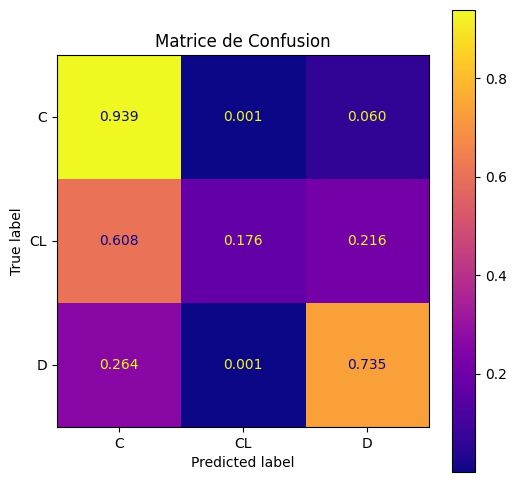

In [56]:
# XGBoost : 
X = train_new2.drop(['id', 'Status'], axis=1) 
y = train_new2['Status']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=0,
    colsample_bytree=0.8,
    gamma=0.2,
    learning_rate=0.1,
    max_depth=4,
    n_estimators=150,
    subsample=0.8
)

best_model_xgb.fit(X_train, y_train)

y_pred_proba = best_model_xgb.predict_proba(X_test)
logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss}")

y_pred = best_model_xgb.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

k_fold = KFold(n_splits=4, shuffle=True, random_state=42)
accuracy = cross_val_score(best_model_xgb, X, y, cv=k_fold, scoring='accuracy', n_jobs=-1)

print("Précisions de la validation croisée avec XGBoost:", accuracy)
print("Précision finale du XGBoost (moyenne):", round(np.mean(accuracy), 4))

print("*" * len("Précision finale du XGBoost (moyenne): x.xxxx"))

print("Matrice de confusion de ce modèle:")

y_pred = best_model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred, normalize='true') 

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['C', 'CL', 'D'])

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap='plasma', ax=ax, values_format=".3f")  # Ajoute les valeurs avec 3 décimales
plt.title("Matrice de Confusion")
plt.show()

 Log Loss: 0.3713

 Rapport de Classification:
              precision    recall  f1-score   support

           C       0.88      0.93      0.90      2006
          CL       0.62      0.22      0.32        74
           D       0.83      0.76      0.79       920

    accuracy                           0.86      3000
   macro avg       0.77      0.64      0.67      3000
weighted avg       0.86      0.86      0.85      3000

Précisions de la validation croisée avec XGBoost: [0.8576     0.8568     0.85066667 0.8576    ]
Précision finale du XGBoost (moyenne): 0.8557
*********************************************
Matrice de confusion de ce modèle:


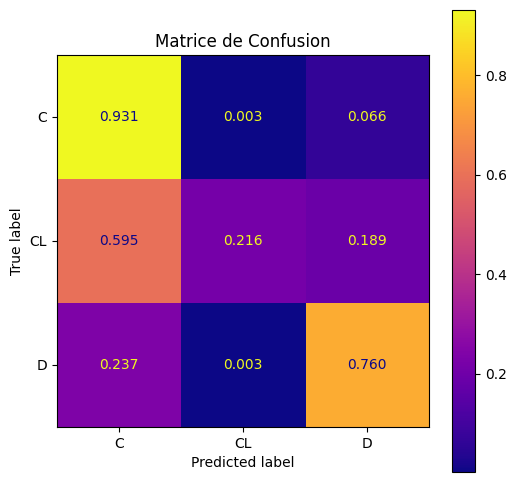

In [57]:
# avec les hyperparamètres trouvés avant: 
X = train_new2.drop(['id', 'Status'], axis=1) 
y = train_new2['Status']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model_xgb2 = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    colsample_bytree=0.14198953405080517,
    gamma=1.8110005586084708e-08,
    learning_rate=0.07244128492444549,
    max_depth=6,
    n_estimators=931,
    subsample=0.7387879239640978,
    reg_alpha=0.7206512712096103,
    reg_lambda=0.33555254247327354,
    min_child_weight=1
)

best_model_xgb2.fit(X_train, y_train)

y_pred_proba = best_model_xgb2.predict_proba(X_test)
logloss = log_loss(y_test, y_pred_proba)
print(f" Log Loss: {logloss:.4f}")

y_pred = best_model_xgb2.predict(X_test)
print("\n Rapport de Classification:")
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

k_fold = KFold(n_splits=4, shuffle=True, random_state=42)
accuracy = cross_val_score(best_model_xgb2, X, y, cv=k_fold, scoring='accuracy', n_jobs=-1)

print("Précisions de la validation croisée avec XGBoost:", accuracy)
print("Précision finale du XGBoost (moyenne):", round(np.mean(accuracy), 4))

print("*" * len("Précision finale du XGBoost (moyenne): x.xxxx"))

print("Matrice de confusion de ce modèle:")

y_pred2 = best_model_xgb2.predict(X_test)

cm2 = confusion_matrix(y_test, y_pred, normalize='true') 

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['C', 'CL', 'D'])

fig, ax = plt.subplots(figsize=(6,6))
disp2.plot(cmap='plasma', ax=ax, values_format=".3f") 
plt.title("Matrice de Confusion")
plt.show()

On prédit bien la classe C, un peu moins bien la classe D, et très mal la classe CL, qui est minoritaire et souffre du déséquilibre des classes.

59,5% des vrais CL sont prédits comme C et seulement 21,6% sont correctement classés. Enfin, 18,9% sont confondus avec la classe D.

Nous allons chercher à améliorer davantage le modèle. Le problème vient probablement du fait que les données sont générées artificiellement et contiennent de nombreuses valeurs manquantes. Leur imputation risque d'altérer significativement l'information.

Voyons si nous pouvons améliorer les résultats en remplaçant les valeurs manquantes par une modalité spécifique, comme "Non répondant".

In [58]:
train_na = train.copy()
test_na = test.copy()

In [59]:
cat_cols = ["Drug", "Ascites", "Hepatomegaly", "Spiders"]
for col in cat_cols:
    train_na[col] = train_na[col].fillna("Non-responder")
    test_na[col] = test_na[col].fillna("Non-responder")

In [60]:
train_na.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           15000 non-null  object 
 3   Age            15000 non-null  int64  
 4   Sex            15000 non-null  object 
 5   Ascites        15000 non-null  object 
 6   Hepatomegaly   15000 non-null  object 
 7   Spiders        15000 non-null  object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    6669 non-null   float64
 11  Albumin        15000 non-null  float64
 12  Copper         8452 non-null   float64
 13  Alk_Phos       8558 non-null   float64
 14  SGOT           8555 non-null   float64
 15  Tryglicerides  6630 non-null   float64
 16  Platelets      14414 non-null  float64
 17  Prothrombin    14974 non-null  float64
 18  Stage 

In [61]:
# KNNImputer pour les colonnes numériques pour l'imputation
num_cols = ['Cholesterol', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']
imputer = KNNImputer(n_neighbors=122) #tester avec k=1

train_na[num_cols] = imputer.fit_transform(train_na[num_cols])
test_na[num_cols] = imputer.fit_transform(test_na[num_cols])
train_na.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15000 non-null  int64  
 1   N_Days         15000 non-null  float64
 2   Drug           15000 non-null  object 
 3   Age            15000 non-null  int64  
 4   Sex            15000 non-null  object 
 5   Ascites        15000 non-null  object 
 6   Hepatomegaly   15000 non-null  object 
 7   Spiders        15000 non-null  object 
 8   Edema          15000 non-null  object 
 9   Bilirubin      15000 non-null  float64
 10  Cholesterol    15000 non-null  float64
 11  Albumin        15000 non-null  float64
 12  Copper         15000 non-null  float64
 13  Alk_Phos       15000 non-null  float64
 14  SGOT           15000 non-null  float64
 15  Tryglicerides  15000 non-null  float64
 16  Platelets      15000 non-null  float64
 17  Prothrombin    15000 non-null  float64
 18  Stage 

In [62]:
test_na.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   N_Days         10000 non-null  float64
 2   Drug           10000 non-null  object 
 3   Age            10000 non-null  int64  
 4   Sex            10000 non-null  object 
 5   Ascites        10000 non-null  object 
 6   Hepatomegaly   10000 non-null  object 
 7   Spiders        10000 non-null  object 
 8   Edema          10000 non-null  object 
 9   Bilirubin      10000 non-null  float64
 10  Cholesterol    10000 non-null  float64
 11  Albumin        10000 non-null  float64
 12  Copper         10000 non-null  float64
 13  Alk_Phos       10000 non-null  float64
 14  SGOT           10000 non-null  float64
 15  Tryglicerides  10000 non-null  float64
 16  Platelets      10000 non-null  float64
 17  Prothrombin    10000 non-null  float64
 18  Stage  

In [63]:
train_na2 = train_na.copy()
test_na2 = test_na.copy() 

colonnes_to_normalize = ['Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 
                         'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']


# normalisation avec PowerTransformer (Yeo-Johnson)
transformer = PowerTransformer(method='yeo-johnson')
train_na2[colonnes_to_normalize] = transformer.fit_transform(train_na2[colonnes_to_normalize])

test_na2[colonnes_to_normalize] = transformer.transform(test_na2[colonnes_to_normalize])

In [64]:
# encoding:
label = "Status"
label_encoder = LabelEncoder()
train_na2[label] = label_encoder.fit_transform(train_na2[label]) # encoding target

encoders = {
    'Drug': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, categories=[['Placebo', 'D-penicillamine']]),
    'Sex': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Ascites': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Hepatomegaly': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Spiders': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Edema': OneHotEncoder(),
    'Stage': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
}

In [65]:
for feat, enc in encoders.items():
    if isinstance(enc, OrdinalEncoder):
        train_na2[feat] = enc.fit_transform(train_na2[[feat]]).astype('int32')
        test_na2[feat] = enc.transform(test_na2[[feat]]).astype('int32')
    if isinstance(enc, OneHotEncoder): 
        new_cols = enc.fit_transform(train_na2[[feat]]).toarray().astype('int8')
        col_names = enc.get_feature_names_out()
        
        train_na2[col_names] = new_cols
        train_na2.drop(feat, axis=1, inplace=True)
        
        new_cols_test = enc.transform(test_na2[[feat]]).toarray().astype('int8')
        test_na2[col_names] = new_cols_test
        test_na2.drop(feat, axis=1, inplace=True)
train_na2.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Bilirubin,Cholesterol,...,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status,Edema_N,Edema_S,Edema_Y
0,0,1055.0,-1,54,0,1,1,1,0.394125,-0.144679,...,0.091516,-0.294845,-0.295339,-0.406567,-0.040140,2,0,1,0,0
1,1,3282.0,0,49,0,0,2,2,-0.705394,0.332532,...,-0.198893,-0.686361,0.234120,-0.053611,2.020447,3,0,1,0,0
2,2,1653.0,-1,56,0,1,1,1,1.095203,-0.065264,...,0.030248,-0.474317,0.622356,-1.312895,-1.998984,1,0,1,0,0
3,3,999.0,1,62,0,0,2,0,-0.044473,2.011354,...,0.461943,1.642832,-0.615679,1.438070,-1.533354,2,0,1,0,0
4,4,2202.0,-1,49,0,1,1,1,1.972027,-0.036492,...,0.448027,-0.333719,-0.168178,1.759261,0.904917,2,0,1,0,0


In [66]:
# le modèle 
X = train_na2.drop(['id', 'Status'], axis=1) 
y = train_na2['Status']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(multi_class='multinomial', solver='newton-cg', max_iter=10000)
# solver='lbfgs' par défaut

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)

logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss}")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))
# solver='saga'
# solver='lbfgs'

Log Loss: 0.4392637671973603
              precision    recall  f1-score   support

           C       0.85      0.92      0.88      2006
          CL       0.25      0.01      0.03        74
           D       0.78      0.70      0.74       920

    accuracy                           0.83      3000
   macro avg       0.63      0.55      0.55      3000
weighted avg       0.81      0.83      0.82      3000



In [67]:
# le modèle 
# avec test_size=0.1
X = train_na2.drop(['id', 'Status'], axis=1) 
y = train_na2['Status']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

model = LogisticRegression(multi_class='multinomial', solver='newton-cg', max_iter=10000)
# solver='lbfgs' par défaut

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)

logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss}")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

Log Loss: 0.42285803905413444
              precision    recall  f1-score   support

           C       0.86      0.92      0.89      1016
          CL       0.00      0.00      0.00        32
           D       0.78      0.71      0.74       452

    accuracy                           0.84      1500
   macro avg       0.55      0.54      0.54      1500
weighted avg       0.82      0.84      0.83      1500



Log Loss: 0.3731976051436028
              precision    recall  f1-score   support

           C       0.87      0.93      0.90      2006
          CL       0.75      0.16      0.27        74
           D       0.82      0.74      0.78       920

    accuracy                           0.86      3000
   macro avg       0.81      0.61      0.65      3000
weighted avg       0.85      0.86      0.85      3000

Précisions de la validation croisée avec XGBoost: [0.85306667 0.8592     0.84426667 0.85466667]
Précision finale du XGBoost (moyenne): 0.8528
*********************************************
Matrice de confusion de ce modèle:


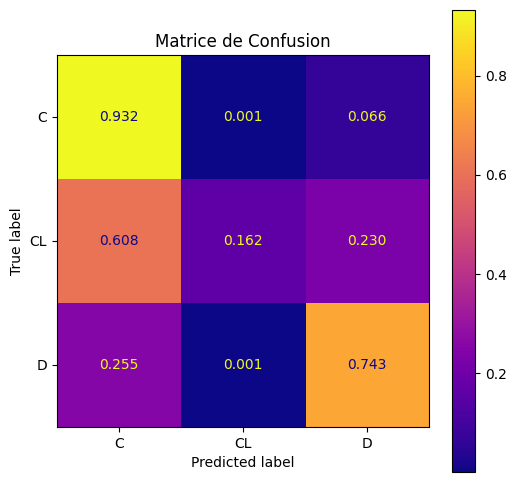

In [68]:
# XGBoost : 
X = train_na2.drop(['id', 'Status'], axis=1) 
y = train_na2['Status']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model_xgb = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=0,
    colsample_bytree=0.8,
    gamma=0.2,
    learning_rate=0.1,
    max_depth=4,
    n_estimators=150,
    subsample=0.8
)

best_model_xgb.fit(X_train, y_train)

y_pred_proba = best_model_xgb.predict_proba(X_test)
logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss}")

y_pred = best_model_xgb.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

k_fold = KFold(n_splits=4, shuffle=True, random_state=42)
accuracy = cross_val_score(best_model_xgb, X, y, cv=k_fold, scoring='accuracy', n_jobs=-1)

print("Précisions de la validation croisée avec XGBoost:", accuracy)
print("Précision finale du XGBoost (moyenne):", round(np.mean(accuracy), 4))

print("*" * len("Précision finale du XGBoost (moyenne): x.xxxx"))

print("Matrice de confusion de ce modèle:")

y_pred = best_model_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred, normalize='true') 

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['C', 'CL', 'D'])

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap='plasma', ax=ax, values_format=".3f")  # Ajoute les valeurs avec 3 décimales
plt.title("Matrice de Confusion")
plt.show()

 Log Loss: 0.3713

 Rapport de Classification:
              precision    recall  f1-score   support

           C       0.88      0.93      0.90      2006
          CL       0.62      0.22      0.32        74
           D       0.83      0.76      0.79       920

    accuracy                           0.86      3000
   macro avg       0.77      0.64      0.67      3000
weighted avg       0.86      0.86      0.85      3000

Précisions de la validation croisée avec XGBoost: [0.8576     0.8568     0.85066667 0.8576    ]
Précision finale du XGBoost (moyenne): 0.8557
*********************************************
Matrice de confusion de ce modèle:


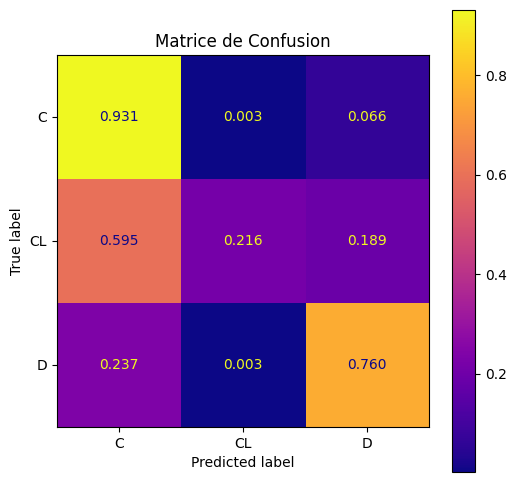

In [69]:
# avec les hyperparamètres trouvés avant: 
X = train_new2.drop(['id', 'Status'], axis=1) 
y = train_new2['Status']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model_xgb2 = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    colsample_bytree=0.14198953405080517,
    gamma=1.8110005586084708e-08,
    learning_rate=0.07244128492444549,
    max_depth=6,
    n_estimators=931,
    subsample=0.7387879239640978,
    reg_alpha=0.7206512712096103,
    reg_lambda=0.33555254247327354,
    min_child_weight=1
)

best_model_xgb2.fit(X_train, y_train)

y_pred_proba = best_model_xgb2.predict_proba(X_test)
logloss = log_loss(y_test, y_pred_proba)
print(f" Log Loss: {logloss:.4f}")

y_pred = best_model_xgb2.predict(X_test)
print("\n Rapport de Classification:")
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

k_fold = KFold(n_splits=4, shuffle=True, random_state=42)
accuracy = cross_val_score(best_model_xgb2, X, y, cv=k_fold, scoring='accuracy', n_jobs=-1)

print("Précisions de la validation croisée avec XGBoost:", accuracy)
print("Précision finale du XGBoost (moyenne):", round(np.mean(accuracy), 4))

print("*" * len("Précision finale du XGBoost (moyenne): x.xxxx"))

print("Matrice de confusion de ce modèle:")

y_pred2 = best_model_xgb2.predict(X_test)

cm2 = confusion_matrix(y_test, y_pred, normalize='true') 

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['C', 'CL', 'D'])

fig, ax = plt.subplots(figsize=(6,6))
disp2.plot(cmap='plasma', ax=ax, values_format=".3f") 
plt.title("Matrice de Confusion")
plt.show()

In [70]:
# X = train_na2.drop(['id', 'Status'], axis=1)
# y = train_na2['Status']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# number_of_trials = 2000
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# def objective_xgb(trial):
#     xgb_params = {
#         'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
#         'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
#         'max_depth': trial.suggest_int('max_depth', 2, 15),
#         'eta': trial.suggest_float('eta', 0.001, 0.1, log=True),
#         'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1.0),
#         'subsample': trial.suggest_float('subsample', 0.1, 1.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
#         'n_estimators': trial.suggest_int('n_estimators', 500, 1000),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
#     }

#     model_xgb = xgb.XGBClassifier(**xgb_params, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)

#     cv_scores = []
#     for train_idx, val_idx in skf.split(X_train, y_train):
#         X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
#         Y_tr, Y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

#         eval_set = [(X_va, Y_va)]
#         model_xgb.fit(X_tr, Y_tr, eval_set=eval_set, verbose=0)

#         y_val_pred_xgb = model_xgb.predict_proba(X_va)
#         fold_score = log_loss(Y_va, y_val_pred_xgb)
#         cv_scores.append(fold_score)

#     return np.mean(cv_scores)

# study_xgb = optuna.create_study(direction='minimize')
# study_xgb.optimize(objective_xgb, n_trials=number_of_trials)

# best_params = study_xgb.best_params

# best_model_xgb = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
# best_model_xgb.fit(X_train, y_train)

# y_pred_proba = best_model_xgb.predict_proba(X_test)
# logloss = log_loss(y_test, y_pred_proba)
# print(f"Log Loss: {logloss}")

# y_pred = best_model_xgb.predict(X_test)
# print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

# cm = confusion_matrix(y_test, y_pred, normalize='true')
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['C', 'CL', 'D'])
# fig, ax = plt.subplots(figsize=(6,6))
# disp.plot(cmap='plasma', ax=ax, values_format=".3f")
# plt.title("Matrice de Confusion")
# plt.show()

# fig, ax = plt.subplots()
# history = study_xgb.trials_dataframe()
# ax.plot(history['value'], label='Objective Value')
# ax.set_xlabel('Iteration')
# ax.set_ylabel('Objective Value')
# ax.set_title('Optimization History')
# ax.legend()
# plt.show()

In [71]:
# [I 2025-02-01 19:12:09,736] Trial 565 finished with value: 0.3670356147128127 and parameters: {'lambda': 0.00048724196642434763, 'alpha': 0.0029513351149976766, 'max_depth': 11, 'eta': 0.005266395355269109, 'gamma': 0.4972665417299552, 'colsample_bytree': 0.12115541887277378, 'subsample': 0.9041062111873353, 'min_child_weight': 1, 'n_estimators': 572, 'learning_rate': 0.05972127876219657, 'reg_alpha': 0.3309324581458315, 'reg_lambda': 0.11739974779314179}. Best is trial 565 with value: 0.3670356147128127.

 Log Loss: 0.3604

 Rapport de Classification:
              precision    recall  f1-score   support

           C       0.87      0.94      0.90      2006
          CL       0.85      0.15      0.25        74
           D       0.83      0.75      0.79       920

    accuracy                           0.86      3000
   macro avg       0.85      0.61      0.65      3000
weighted avg       0.86      0.86      0.85      3000

Précisions de la validation croisée avec XGBoost: [0.85653333 0.86106667 0.85253333 0.86133333]
Précision finale du XGBoost (moyenne): 0.8579
*********************************************
Matrice de confusion de ce modèle:


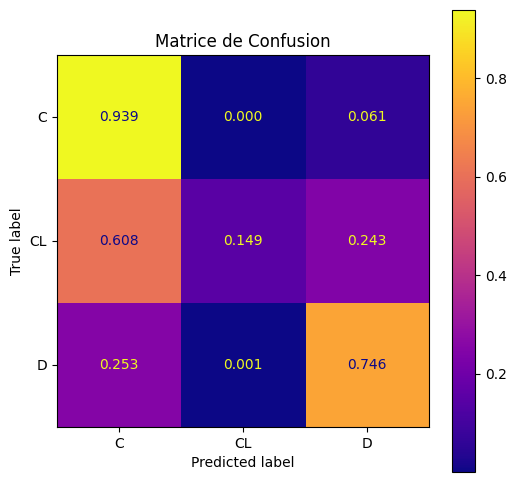

In [72]:
X = train_new2.drop(['id', 'Status'], axis=1)
y = train_new2['Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model_xgb2 = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    colsample_bytree=0.12115541887277378,
    gamma=0.4972665417299552,
    learning_rate=0.05972127876219657,
    max_depth=11,
    n_estimators=572,
    subsample=0.9041062111873353,
    reg_alpha=0.3309324581458315,
    reg_lambda=0.11739974779314179,
    min_child_weight=1
)

best_model_xgb2.fit(X_train, y_train)

y_pred_proba = best_model_xgb2.predict_proba(X_test)
logloss = log_loss(y_test, y_pred_proba)
print(f" Log Loss: {logloss:.4f}")

y_pred = best_model_xgb2.predict(X_test)
print("\n Rapport de Classification:")
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

k_fold = KFold(n_splits=4, shuffle=True, random_state=42)
accuracy = cross_val_score(best_model_xgb2, X, y, cv=k_fold, scoring='accuracy', n_jobs=-1)

print("Précisions de la validation croisée avec XGBoost:", accuracy)
print("Précision finale du XGBoost (moyenne):", round(np.mean(accuracy), 4))

print("*" * len("Précision finale du XGBoost (moyenne): x.xxxx"))

print("Matrice de confusion de ce modèle:")

y_pred2 = best_model_xgb2.predict(X_test)
cm2 = confusion_matrix(y_test, y_pred, normalize='true')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['C', 'CL', 'D'])

fig, ax = plt.subplots(figsize=(6,6))
disp2.plot(cmap='plasma', ax=ax, values_format=".3f") 
plt.title("Matrice de Confusion")
plt.show()

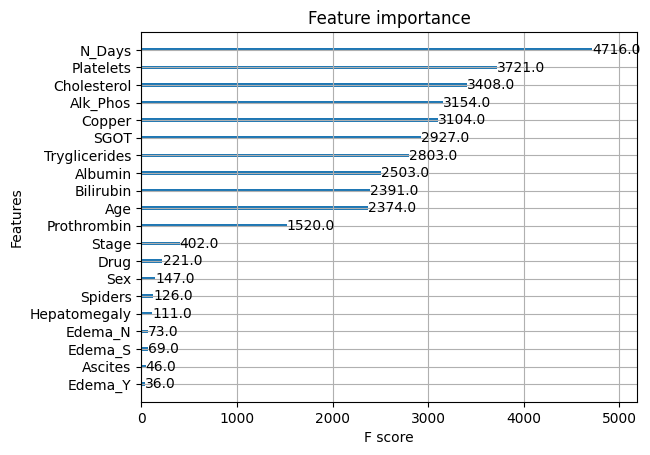

In [73]:
xgb.plot_importance(best_model_xgb2)
plt.show()

In [74]:
#test_na2.head()

In [75]:
#X_test_final = test_na2.drop(['id'], axis=1)

#y_test_proba = best_model_xgb2.predict_proba(X_test_final)

#df_results = test_na2[['id']].copy()
#df_results['Status_C'] = y_test_proba[:, 0]
#df_results['Status_CL'] = y_test_proba[:, 1]
#df_results['Status_D'] = y_test_proba[:, 2]

#df_results.head(10)

In [76]:
#df_results.to_csv('/kaggle/working/df_results_xgb_different_test2fev.csv', index=False)

Comptage de chaque statut :
Status
C     10049
D      4560
CL      391
Name: count, dtype: int64



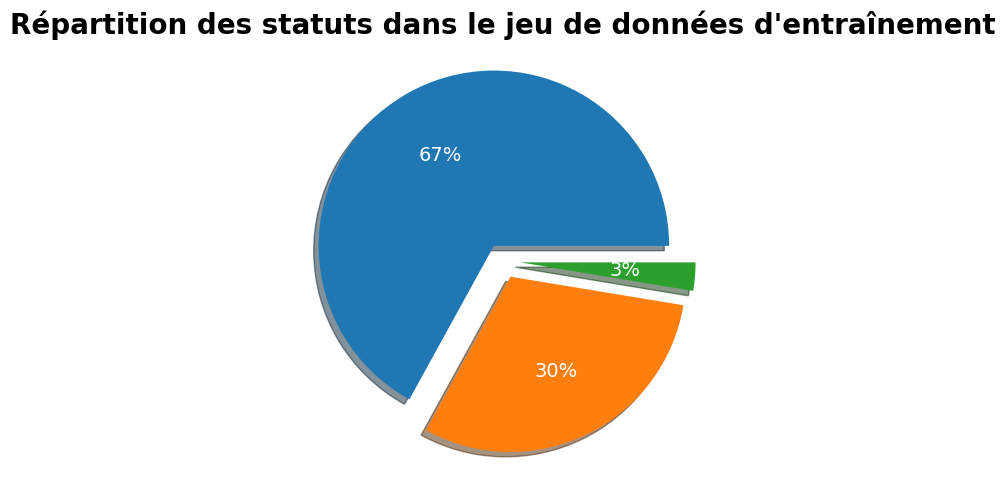

In [77]:
status_counts = train['Status'].value_counts()
print("Comptage de chaque statut :")
print(status_counts)
print()

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.pie(
    train['Status'].value_counts(), 
    shadow=True, 
    explode=[.1 for i in range(train['Status'].nunique())],  # ajuster l'explosion en fonction du nombre de valeurs uniques
    autopct='%1.f%%',
    textprops={'size': 14, 'color': 'white'}
)

ax.set_title('Répartition des statuts dans le jeu de données d\'entraînement', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

Dans le graphique ci-dessus, on peut voir qu'il y a très peu d'occurrences de CL (3% seulement).

Pour résoudre ce déséquilibre, nous avons utilisé SMOTE.

Bien que SMOTE ait augmenté (très légèrement) la précision globale des modèles, le score de soumission était moins bon. On a donc abandonné cette stratégie.

https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html

En nous appuyant sur le notebook Kaggle https://www.kaggle.com/code/arunklenin/ps3e26-cirrhosis-survial-prediction-multiclass#4.-IMPUTE-MISSING-VALUES, nous avons décidé d'imputer les valeurs manquantes, à la fois numériques et catégorielles, en utilisant respectivement CatBoostRegressor et CatBoostClassifier. 

Un modèle est entraîné pour chaque colonne avec des valeurs manquantes en fonction des autres caractéristiques disponibles.

In [78]:
train_cat = train.copy()
test_cat = test.copy()

In [79]:
# à peu près le même % de NA dans les variables type 'Object'
missing_cat=[f for f in train_cat.columns if train_cat[f].dtype=="O" and train_cat[f].isna().sum()>0]
train_missing_pct = train_cat[missing_cat].isnull().mean() * 100
test_missing_pct = test_cat[missing_cat].isnull().mean() * 100

missing_pct_df = pd.concat([train_missing_pct, test_missing_pct], axis=1, keys=['Train %', 'Test%'])
print(missing_pct_df)

                Train %  Test%
Drug          42.906667  43.41
Ascites       42.926667  43.34
Hepatomegaly  42.913333  43.35
Spiders       42.966667  43.41


In [80]:
cat_params={
            'depth': 6,
            'learning_rate': 0.1,
            'l2_leaf_reg': 0.7,
            'random_strength': 0.2,
            'max_bin': 200,
            'od_wait': 65,
            'one_hot_max_size': 70,
            'grow_policy': 'Depthwise',
            'bootstrap_type': 'Bayesian',
            'od_type': 'Iter',
            'eval_metric': 'MultiClass',
            'loss_function': 'MultiClass',
}
def store_missing_rows(df, features):
    missing_rows = {}
    
    for feature in features:
        missing_rows[feature] = df[df[feature].isnull()]
    
    return missing_rows

def fill_missing_categorical(train, test, target, features, max_iterations=10):
    df = pd.concat([train.drop(columns=target), test], axis="rows")
    df = df.reset_index(drop=True)

    missing_rows = store_missing_rows(df, features)

    for f in features:
        df[f] = df[f].fillna("Missing_" + f)

    for iteration in tqdm(range(max_iterations), desc="Iterations"):
        for feature in features:
            rows_miss = missing_rows[feature].index

            missing_temp = df.loc[rows_miss].copy()
            non_missing_temp = df.drop(index=rows_miss).copy()
            missing_temp = missing_temp.drop(columns=[feature])

            other_features = [x for x in df.columns if x != feature and df[x].dtype == "O"]

            X_train = non_missing_temp.drop(columns=[feature])
            y_train = non_missing_temp[[feature]]

            catboost_classifier = CatBoostClassifier(**cat_params)
            catboost_classifier.fit(X_train, y_train, cat_features=other_features, verbose=False)

            y_pred = catboost_classifier.predict(missing_temp)
            
            if y_pred.dtype != "O":
                y_pred = y_pred.astype(str)

            df.loc[rows_miss, feature] = y_pred

    train[features] = np.array(df.iloc[:train.shape[0]][features])
    test[features] = np.array(df.iloc[train.shape[0]:][features])

    return train, test

train_cat, test_cat = fill_missing_categorical(train_cat, test_cat, 'Status', missing_cat, 5)

Iterations: 100%|██████████| 5/5 [05:00<00:00, 60.14s/it]


In [81]:
# à peu près le même % de NA dans les variables numériques
missing_num=[f for f in train_cat.columns if train_cat[f].dtype!="O" and train_cat[f].isna().sum()>0]
train_missing_pct = train_cat[missing_num].isnull().mean() * 100
test_missing_pct = test_cat[missing_num].isnull().mean() * 100
missing_pct_df = pd.concat([train_missing_pct, test_missing_pct], axis=1, keys=['Train %', 'Test%'])
print(missing_pct_df)

                 Train %  Test%
Cholesterol    55.540000  55.62
Copper         43.653333  43.96
Alk_Phos       42.946667  43.40
SGOT           42.966667  43.44
Tryglicerides  55.800000  55.93
Platelets       3.906667   3.75
Prothrombin     0.173333   0.11


Iterations: 100%|██████████| 5/5 [02:26<00:00, 29.25s/it]


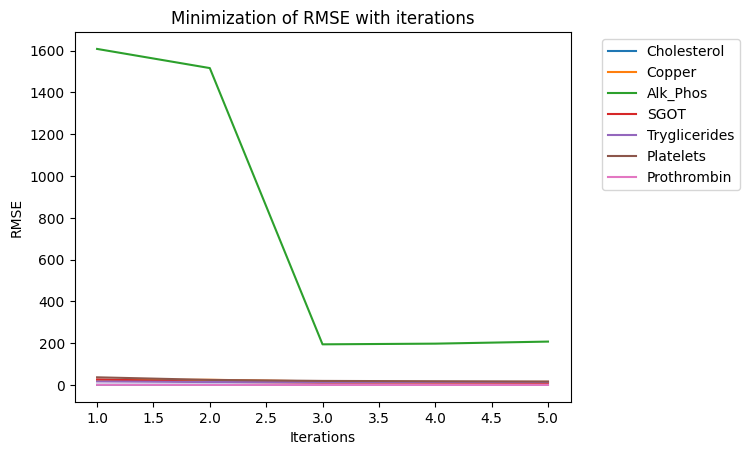

In [82]:
cb_params = {
            'iterations': 500,
            'depth': 6,
            'learning_rate': 0.02,
            'l2_leaf_reg': 0.5,
            'random_strength': 0.2,
            'max_bin': 150,
            'od_wait': 80,
            'one_hot_max_size': 70,
            'grow_policy': 'Depthwise',
            'bootstrap_type': 'Bayesian',
            'od_type': 'IncToDec',
            'eval_metric': 'RMSE',
            'loss_function': 'RMSE',
            'random_state': 42,
        }
lgb_params = {
            'n_estimators': 50,
            'max_depth': 8,
            'learning_rate': 0.02,
            'subsample': 0.20,
            'colsample_bytree': 0.56,
            'reg_alpha': 0.25,
            'reg_lambda': 5e-08,
            'objective': 'multiclass',
            'metric': 'multi_logloss',
            'boosting_type': 'gbdt',
            'random_state': 42,
        }
def rmse(y1,y2):
    return(np.sqrt(mean_squared_error(y1,y2)))

def fill_missing_numerical(train,test,target, features, max_iterations=10):
    train_temp=train.copy()
    if target in train_temp.columns:
        train_temp=train_temp.drop(columns=target)
        
    
    df=pd.concat([train_temp,test],axis="rows")
    df=df.reset_index(drop=True)
    
    missing_rows = store_missing_rows(df, features)
    
    for f in features:
        df[f]=df[f].fillna(df[f].mean())
    
    cat_features=[f for f in df.columns if not pd.api.types.is_numeric_dtype(df[f])]
    dictionary = {feature: [] for feature in features}
    
    for iteration in tqdm(range(max_iterations), desc="Iterations"):
        for feature in features:
            rows_miss = missing_rows[feature].index
            
            missing_temp = df.loc[rows_miss].copy()
            non_missing_temp = df.drop(index=rows_miss).copy()
            y_pred_prev=missing_temp[feature]
            missing_temp = missing_temp.drop(columns=[feature])
            
            
            X_train = non_missing_temp.drop(columns=[feature])
            y_train = non_missing_temp[[feature]]
            
            model = CatBoostRegressor(**cb_params)

            model.fit(X_train, y_train,cat_features=cat_features, verbose=False)
            
            y_pred = model.predict(missing_temp)
            df.loc[rows_miss, feature] = y_pred
            error_minimize=rmse(y_pred,y_pred_prev)
            dictionary[feature].append(error_minimize)  # Append the error_minimize value

    for feature, values in dictionary.items():
        iterations = range(1, len(values) + 1)  # x-axis values (iterations)
        plt.plot(iterations, values, label=feature)  # plot the values
        plt.xlabel('Iterations')
        plt.ylabel('RMSE')
        plt.title('Minimization of RMSE with iterations')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
    train[features] = np.array(df.iloc[:train.shape[0]][features])
    test[features] = np.array(df.iloc[train.shape[0]:][features])

    return train,test


train_cat,test_cat = fill_missing_numerical(train_cat,test_cat,'Status',missing_num,5)

Nous avons ici les intervalles des différentes mesures dites 'normales':

- Bilirubine : 0.1 à 1.2 mg/dl
- Cholestérol : 125 à 200 mg/dl
- Albumine : 3.4 à 5.4 gm/dl
- Cuivre : 10-30 ug/jour
- Phosphatase alcaline : 40 à 129 U/litre
- SGOT : 8 à 45 U/L
- Triglycérides : 48.68 à 168.15 mg/dL
- Plaquettes : 150 à 400 unités
- Temps de Prothrombine : 11 à 13.5 secondes

Or, pour la mesure de la Phosphatase alcaline (Alkaline Phosphatase = Alk_phos), nous observons des valeurs anormalement élevées, de l'ordre de plusieurs dizaines de milliers, ce qui fausse toute l'information. Cela explique pourquoi nous constatons un RMSE aussi élevé par rapport à d'autres mesures prédites.

In [83]:
train_cat2 = train_cat.copy()
test_cat2 = test_cat.copy() 

colonnes_to_normalize = ['Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 
                         'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']


# normalisation avec PowerTransformer (Yeo-Johnson)
transformer = PowerTransformer(method='yeo-johnson')
train_cat2[colonnes_to_normalize] = transformer.fit_transform(train_cat2[colonnes_to_normalize])

test_cat2[colonnes_to_normalize] = transformer.transform(test_cat2[colonnes_to_normalize])

In [84]:
# encoding:
label = "Status"
label_encoder = LabelEncoder()
train_cat2[label] = label_encoder.fit_transform(train_cat2[label]) # encoding target

encoders = {
    'Drug': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, categories=[['Placebo', 'D-penicillamine']]),
    'Sex': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Ascites': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Hepatomegaly': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Spiders': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Edema': OneHotEncoder(),
    'Stage': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
}

In [85]:
for feat, enc in encoders.items():
    if isinstance(enc, OrdinalEncoder):
        train_cat2[feat] = enc.fit_transform(train_cat2[[feat]]).astype('int32')
        test_cat2[feat] = enc.transform(test_cat2[[feat]]).astype('int32')
    if isinstance(enc, OneHotEncoder): 
        new_cols = enc.fit_transform(train_cat2[[feat]]).toarray().astype('int8')
        col_names = enc.get_feature_names_out()
        
        train_cat2[col_names] = new_cols
        train_cat2.drop(feat, axis=1, inplace=True)
        
        new_cols_test = enc.transform(test_cat2[[feat]]).toarray().astype('int8')
        test_cat2[col_names] = new_cols_test
        test_cat2.drop(feat, axis=1, inplace=True)
train_cat2.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Bilirubin,Cholesterol,...,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status,Edema_N,Edema_S,Edema_Y
0,0,1055.0,1,54,0,0,0,0,0.394125,0.291148,...,0.390340,0.602675,0.019866,-0.408706,-0.040403,2,0,1,0,0
1,1,3282.0,0,49,0,0,1,1,-0.705394,-0.036135,...,-0.316291,-1.189300,0.026098,-0.057348,2.019846,3,0,1,0,0
2,2,1653.0,1,56,0,0,1,0,1.095203,0.167844,...,0.453449,0.561037,-0.105952,-1.309717,-1.998642,1,0,1,0,0
3,3,999.0,1,62,0,0,1,0,-0.044473,1.495679,...,0.309402,1.032884,-0.747768,1.430039,-1.533176,2,0,1,0,0
4,4,2202.0,1,49,0,0,1,0,1.972027,2.427291,...,1.438064,1.352862,0.946917,1.750766,0.904451,2,0,1,0,0


In [86]:
# le modèle 
X = train_cat2.drop(['id', 'Status'], axis=1) 
y = train_cat2['Status']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(multi_class='multinomial', solver='newton-cg', max_iter=10000)
# solver='lbfgs' par défaut

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)

logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss}")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))
# solver='saga'
# solver='lbfgs'

Log Loss: 0.43638960781748576
              precision    recall  f1-score   support

           C       0.85      0.92      0.88      2006
          CL       0.00      0.00      0.00        74
           D       0.78      0.70      0.74       920

    accuracy                           0.83      3000
   macro avg       0.54      0.54      0.54      3000
weighted avg       0.81      0.83      0.82      3000



In [87]:
# le modèle 
# avec test_size=0.1
X = train_cat2.drop(['id', 'Status'], axis=1) 
y = train_cat2['Status']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

model = LogisticRegression(multi_class='multinomial', solver='newton-cg', max_iter=10000)
# solver='lbfgs' par défaut

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)

logloss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {logloss}")

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

Log Loss: 0.4200061024956246
              precision    recall  f1-score   support

           C       0.86      0.92      0.89      1016
          CL       0.00      0.00      0.00        32
           D       0.78      0.69      0.73       452

    accuracy                           0.83      1500
   macro avg       0.54      0.54      0.54      1500
weighted avg       0.81      0.83      0.82      1500



 Log Loss: 0.3609

 Rapport de Classification:
              precision    recall  f1-score   support

           C       0.87      0.94      0.90      2006
          CL       0.89      0.11      0.19        74
           D       0.83      0.76      0.79       920

    accuracy                           0.86      3000
   macro avg       0.86      0.60      0.63      3000
weighted avg       0.86      0.86      0.85      3000

Précisions de la validation croisée avec XGBoost: [0.8528     0.85866667 0.84986667 0.86426667]
Précision finale du XGBoost (moyenne): 0.8564
*********************************************
Matrice de confusion de ce modèle:


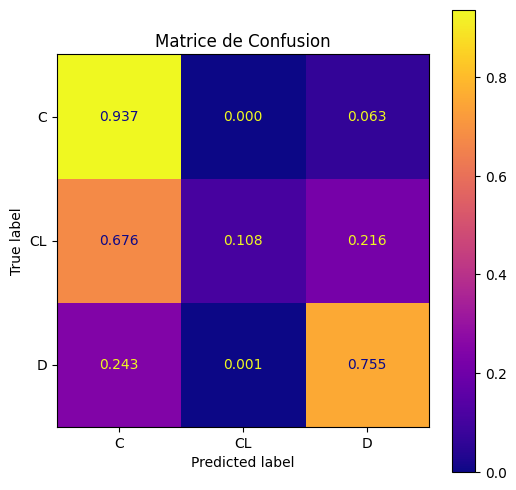

In [88]:
X = train_cat2.drop(['id', 'Status'], axis=1) 
y = train_cat2['Status']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

best_model_xgb2 = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    colsample_bytree=0.12115541887277378,
    gamma=0.4972665417299552,
    learning_rate=0.05972127876219657,
    max_depth=11,
    n_estimators=572,
    subsample=0.9041062111873353,
    reg_alpha=0.3309324581458315,
    reg_lambda=0.11739974779314179,
    min_child_weight=1
)

best_model_xgb2.fit(X_train, y_train)

y_pred_proba = best_model_xgb2.predict_proba(X_test)
logloss = log_loss(y_test, y_pred_proba)
print(f" Log Loss: {logloss:.4f}")

y_pred = best_model_xgb2.predict(X_test)
print("\n Rapport de Classification:")
print(classification_report(y_test, y_pred, target_names=['C', 'CL', 'D']))

k_fold = KFold(n_splits=4, shuffle=True, random_state=42)
accuracy = cross_val_score(best_model_xgb2, X, y, cv=k_fold, scoring='accuracy', n_jobs=-1)

print("Précisions de la validation croisée avec XGBoost:", accuracy)
print("Précision finale du XGBoost (moyenne):", round(np.mean(accuracy), 4))

print("*" * len("Précision finale du XGBoost (moyenne): x.xxxx"))

print("Matrice de confusion de ce modèle:")

y_pred2 = best_model_xgb2.predict(X_test)
cm2 = confusion_matrix(y_test, y_pred, normalize='true')

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['C', 'CL', 'D'])

fig, ax = plt.subplots(figsize=(6,6))
disp2.plot(cmap='plasma', ax=ax, values_format=".3f") 
plt.title("Matrice de Confusion")
plt.show()

In [89]:
X_test_final = test_cat2.drop(['id'], axis=1)

y_test_proba = best_model_xgb2.predict_proba(X_test_final)

df_results = test_cat2[['id']].copy()
df_results['Status_C'] = y_test_proba[:, 0]
df_results['Status_CL'] = y_test_proba[:, 1]
df_results['Status_D'] = y_test_proba[:, 2]

df_results.head(10)

,id,Status_C,Status_CL,Status_D
0,15000,0.893769,0.005041,0.101191
1,15001,0.948278,0.007195,0.044527
2,15002,0.730004,0.015869,0.254127
3,15003,0.980754,0.001135,0.018110
4,15004,0.988667,0.006184,0.005149
5,15005,0.907208,0.049322,0.043470
6,15006,0.795486,0.022467,0.182047
7,15007,0.962048,0.009043,0.028909
8,15008,0.853348,0.018260,0.128392
9,15009,0.539298,0.083764,0.376938


In [90]:
#df_results.to_csv('/kaggle/working/df_results_xgb_catboost_final.csv', index=False)

In [91]:
df_results['Status_predit'] = df_results[['Status_C', 'Status_CL', 'Status_D']].idxmax(axis=1)

In [92]:
# prédit seulement 33 observations pour le Status CL 
# le reste est globalement bien réparti
df_results['Status_predit'].value_counts()

Status_predit
Status_C     7315
Status_D     2652
Status_CL      33
Name: count, dtype: int64

Pour terminer, il serait intéressant de créer de nouvelles variables après une étude approfondie des tests réalisés dans cette étude, en y associant une analyse médicale. Cela permettrait de définir des indicateurs concrets et significatifs, comme l'ALBI score, qui est calculé à partir des valeurs d'albumine et de bilirubine, ou le Mayo Risk Score, qui prend en compte l'âge et diverses mesures numériques. Cependant, dans notre cas, cela serait limité, car cela ajouterait du bruit pour les individus pour lesquels nous avons prédit des valeurs manquantes, et ces mêmes valeurs seraient réutilisées pour calculer ces scores, ce qui rendrait l'approche peu efficace.